# Student Depression Classification Notebook

This notebook is aligned to `Student Depression Dataset.csv`. It treats the `Depression` column as a binary target and builds a mixed numeric/categorical preprocessing pipeline that matches the dataset schema.

In [1]:
%matplotlib inline
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = 'Student Depression Dataset.csv'
MODEL_DIR = 'model'
TARGET_COL = 'Depression'
ID_COL = 'id'

NUMERIC_COLS = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress',
]

CATEGORICAL_COLS = [
    'Gender',
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
]

LABEL_MAP = {0: 'No Depression', 1: 'Depression'}
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Using {len(NUMERIC_COLS)} numeric and {len(CATEGORICAL_COLS)} categorical features.')

Using 8 numeric and 5 categorical features.


Dataset shape: 27901 rows x 18 columns


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


Depression
No Depression    11565
Depression       16336
Name: count, dtype: int64

Financial Stress      3
id                    0
Gender                0
Age                   0
Profession            0
City                  0
Work Pressure         0
CGPA                  0
Study Satisfaction    0
Academic Pressure     0
dtype: int64

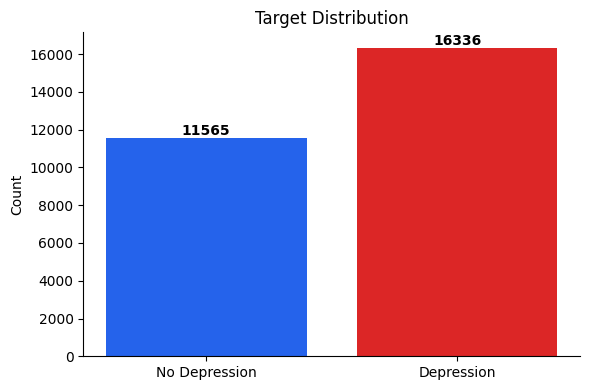

In [3]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

display(df[TARGET_COL].value_counts().sort_index().rename(LABEL_MAP))
display(df.isnull().sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(6, 4))
counts = df[TARGET_COL].value_counts().sort_index()
bars = ax.bar([LABEL_MAP[i] for i in counts.index], counts.values, color=['#2563eb', '#dc2626'])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, str(value), ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
X = df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])
y = df[TARGET_COL].astype(int)

numeric_features = [col for col in NUMERIC_COLS if col in X.columns]
categorical_features = [col for col in CATEGORICAL_COLS if col in X.columns]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
    ]),
}

results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std(), 'test_acc': test_acc, 'pipe': pipe}

comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'Model': name,
        'CV Accuracy': f"{res['cv_mean']:.3f} ± {res['cv_std']:.3f}",
        'Test Accuracy': f"{res['test_acc']:.3f}",
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.845 ± 0.002,0.843
1,Random Forest,0.837 ± 0.001,0.833


Best model: Logistic Regression
Test accuracy: 0.843
ROC AUC: 0.919

               precision    recall  f1-score   support

No Depression       0.80      0.84      0.82      2313
   Depression       0.88      0.85      0.86      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581



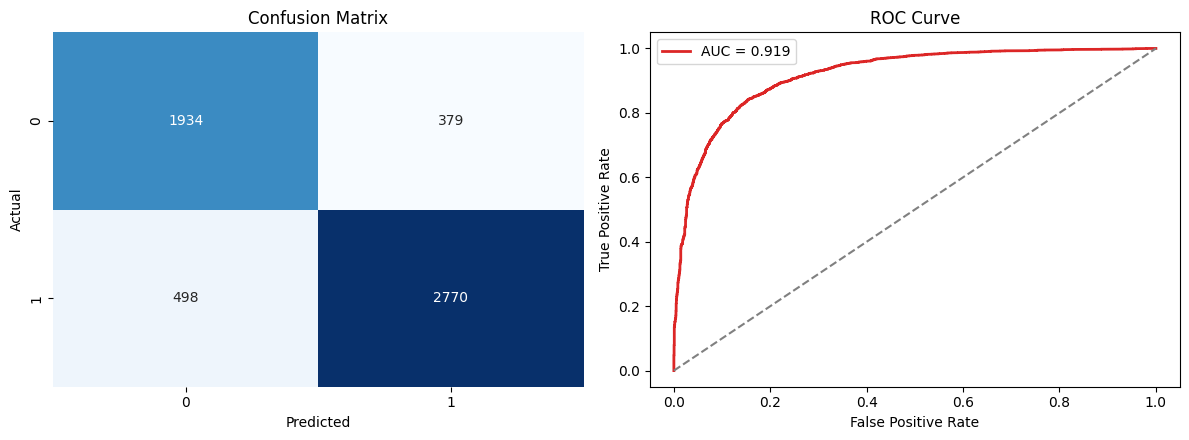

In [6]:
best_name = max(results, key=lambda key: results[key]['test_acc'])
best_model = results[best_name]['pipe']
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'Best model: {best_name}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=list(LABEL_MAP.values())))

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#dc2626', linewidth=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
param_grid = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(
    estimator=candidates['Random Forest'],
    param_distributions=param_grid,
    n_iter=12,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
)
search.fit(X_train, y_train)
tuned_model = search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]
tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_auc = roc_auc_score(y_test, tuned_prob)

baseline_name = max(results, key=lambda key: results[key]['test_acc'])
baseline_model = results[baseline_name]['pipe']
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print('Best Random Forest parameters:')
print(search.best_params_)
print(f'Optimized test accuracy: {tuned_acc:.3f}')
print(f'Optimized ROC AUC: {tuned_auc:.3f}')

if tuned_acc >= baseline_acc:
    final_model = tuned_model
    final_name = 'Tuned Random Forest'
    final_acc = tuned_acc
    final_auc = tuned_auc
else:
    final_model = baseline_model
    final_name = baseline_name
    final_acc = baseline_acc
    final_auc = baseline_auc

joblib.dump(final_model, os.path.join(MODEL_DIR, 'depression_model.pkl'))
joblib.dump({
    'target_col': TARGET_COL,
    'numeric_cols': numeric_features,
    'categorical_cols': categorical_features,
    'label_map': LABEL_MAP,
    'selected_model': final_name,
    'test_accuracy': final_acc,
    'test_auc': final_auc,
}, os.path.join(MODEL_DIR, 'depression_metadata.pkl'))

print(f'Saved model artifacts to {MODEL_DIR}/')
print(f'Selected final model: {final_name}')

Best Random Forest parameters:
{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': 20}
Optimized test accuracy: 0.841
Optimized ROC AUC: 0.916
Saved model artifacts to model/
Selected final model: Logistic Regression


## Summary

The notebook now matches the depression dataset schema instead of the old stress dataset. It uses a binary target, imputes missing values, encodes categorical fields, and saves a trained model plus metadata for reuse.